LOADING IN THE DATA + LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# clones repo into collab files
# run only once per runtime
!git clone https://github.com/Break-Through-Tech/Microsoft-4A-groundwater-timeseries-prediction-using-AI

Cloning into 'Microsoft-4A-groundwater-timeseries-prediction-using-AI'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 90 (delta 45), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 7.34 MiB | 7.40 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [4]:
monthly_filename = os.path.join(
    "/content", "Microsoft-4A-groundwater-timeseries-prediction-using-AI", "data", "nld_regional_105_wells_2012_2022.csv"
)
daily_filename = os.path.join(
    "/content", "Microsoft-4A-groundwater-timeseries-prediction-using-AI", "data", "svn_regional_53_wells_daily_2019_2023.csv"
)

df_monthly = pd.read_csv(monthly_filename, header=0)
df_daily = pd.read_csv(daily_filename, header=0)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

/tmp/ipykernel_635/168685579.py:9: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  df_daily = pd.read_csv(daily_filename, header=0)


DATA PROPROCESSING (DAILY)

In [5]:
# We will work with the daily dataset for the first part of our project because it has much more information.

print("Monthly Dataset Shape")
display(df_monthly.shape)
print("Daily Dataset Shape")
display(df_daily.shape)

Monthly Dataset Shape


(13860, 64)

Daily Dataset Shape


(96778, 65)

In [6]:
# Let's start by skimming over our data, starting with the columns.
for col in df_daily.columns:
    print(col)

GROW_ID
interval
date
year
month
aggregated_from_n_values
outliers_change_points
plateaus
groundwater_water_level_elevation_m_asl
precipitation_mswep_mm_year-1
precipitation_gpcc_mm_year-1
potential_evapotranspiration_era5_mm_year-1
potential_evapotranspiration_gleam_mm_year-1
actual_evapotranspiration_mm_year-1
interception_mm_year-1
air_temperature_°C
snow_depth_m
days_with_snow_cover_days_year-1
ndvi_ratio
lai_low_vegetation_ratio
lai_high_vegetation_ratio
withdrawal_industrial_m3_year-1
withdrawal_domestic_m3_year-1
urban_area_fraction
pastures_fraction
cropland_rainfed_fraction
cropland_irrigated_fraction
forests_natural_vegetation_fraction
original_ID_groundwater
name
feature_type
purpose
status
latitude
longitude
country
aquifer_name
confinement
organisation
license
starting_date
ending_date
length_years
autocorrelation
gap_fraction
trend_direction
trend_slope_m_year-1
reference_point
groundwater_mean_m
groundwater_median_m
koeppen_geiger_class
hydrobelt_class
ground_elevation_m

In [7]:
# Take a preview at our dataset to see if anything stands out.

print("Daily Dataset Preview")
display(df_daily.head())

Daily Dataset Preview


,GROW_ID,interval,date,year,month,aggregated_from_n_values,outliers_change_points,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,precipitation_gpcc_mm_year-1,potential_evapotranspiration_era5_mm_year-1,potential_evapotranspiration_gleam_mm_year-1,actual_evapotranspiration_mm_year-1,interception_mm_year-1,air_temperature_°C,snow_depth_m,days_with_snow_cover_days_year-1,ndvi_ratio,lai_low_vegetation_ratio,lai_high_vegetation_ratio,withdrawal_industrial_m3_year-1,withdrawal_domestic_m3_year-1,urban_area_fraction,pastures_fraction,cropland_rainfed_fraction,cropland_irrigated_fraction,forests_natural_vegetation_fraction,original_ID_groundwater,name,feature_type,purpose,status,latitude,longitude,country,aquifer_name,confinement,organisation,license,starting_date,ending_date,length_years,autocorrelation,gap_fraction,trend_direction,trend_slope_m_year-1,reference_point,groundwater_mean_m,groundwater_median_m,koeppen_geiger_class,hydrobelt_class,ground_elevation_merit_m_asl,topographic_slope_degree,aquifer_type_class,permeability_0-100_m_m-2,total_porosity_0-100_m_fraction,soil_texture_0-30_cm_class,soil_texture_30-200_cm_class,soil_saturated_conductivity_0-30_cm_cm_d-1,soil_saturated_conductivity_30-200_cm_cm_d-1,distance_perennial_streams_m,drainage_density_m-1,main_landuse_class,distance_to_cluster_center_km
0,GROW-18108201772,d,2019-01-01,2019,2019-01,NaN,False,0,304.83,45.625,821.04,109.837026,98.319356,87.170150,28.274261,1.86523,0.007568,82.0,0.3128,2.940338,1.082947,81079016.0,17460536.0,0.028556,0.09373,0.051826,0.0,0.825888,1173,Mengeš (Mp-0275),Water well,Observation / monitoring,NaN,46.180855,14.581305,SVN,NaN,NaN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMATE AND ENERGY",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,20,True,0.000137,decreasing,-0.109268,Water level elevation a.m.s.l.,305.884637,305.38,Cfb,Mid-latitude,332.2,0.75,karst,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
1,GROW-18108201772,d,2019-01-02,2019,2019-01,NaN,False,0,304.79,0.000,821.04,224.211817,102.139899,89.009648,0.000000,0.65912,0.007812,82.0,0.1503,2.940125,1.078125,81079016.0,17460536.0,0.028556,0.09373,0.051826,0.0,0.825888,1173,Mengeš (Mp-0275),Water well,Observation / monitoring,NaN,46.180855,14.581305,SVN,NaN,NaN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMATE AND ENERGY",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,20,True,0.000137,decreasing,-0.109268,Water level elevation a.m.s.l.,305.884637,305.38,Cfb,Mid-latitude,332.2,0.75,karst,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
2,GROW-18108201772,d,2019-01-03,2019,2019-01,NaN,False,0,304.73,0.000,821.04,437.022274,580.862387,454.509862,0.000000,-0.86993,0.007324,82.0,0.4445,2.939972,1.073334,81079016.0,17460536.0,0.028556,0.09373,0.051826,0.0,0.825888,1173,Mengeš (Mp-0275),Water well,Observation / monitoring,NaN,46.180855,14.581305,SVN,NaN,NaN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMATE AND ENERGY",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,20,True,0.000137,decreasing,-0.109268,Water level elevation a.m.s.l.,305.884637,305.38,Cfb,Mid-latitude,332.2,0.75,karst,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
3,GROW-18108201772,d,2019-01-04,2019,2019-01,NaN,False,0,304.68,0.000,821.04,370.233991,523.731382,416.227750,0.000000,-1.03696,0.008057,82.0,0.4081,2.939758,1.068573,81079016.0,17460536.0,0.028556,0.09373,0.051826,0.0,0.825888,1173,Mengeš (Mp-0275),Water well,Observation / monitoring,NaN,46.180855,14.581305,SVN,NaN,NaN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMATE AND ENERGY",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,20,True,0.000137,decreasing,-0.109268,Water level elevation a.m.s.l.,305.884637,305.38,Cfb,Mid-latitude,332.2,0.75,karst,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natu

In [8]:
# There a few columns that potentially stand out. For instance, GROW_ID is likely an identifier for our data and might have nothing to do with the actual findings.
# There are also columns that seem to consist of mostly missing values, such as aggregated_from_n_values. Other columns seem to have one dominant value that most rows have.

# Let's first discuss missing values.

summary = pd.DataFrame({
    "nan_count": df_daily.isna().sum(),
    "nan_pct": (df_daily.isna().mean() * 100).round(2),
})
print(summary.sort_values("nan_pct", ascending=False))

                                              nan_count  nan_pct
aggregated_from_n_values                          96778   100.00
confinement                                       96778   100.00
status                                            96778   100.00
aquifer_name                                      96778   100.00
precipitation_gpcc_mm_year-1                      58035    59.97
trend_slope_m_year-1                              49302    50.94
withdrawal_industrial_m3_year-1                   38690    39.98
urban_area_fraction                               38690    39.98
forests_natural_vegetation_fraction               38690    39.98
withdrawal_domestic_m3_year-1                     38690    39.98
cropland_rainfed_fraction                         38690    39.98
pastures_fraction                                 38690    39.98
cropland_irrigated_fraction                       38690    39.98
soil_texture_30-200_cm_class                      21912    22.64
ndvi_ratio               

In [9]:
# There are a few takeaways from the data above.
# First there are four columns that are missing for all rows in our data. These columns can be dropped with no issue.

missing_cols = summary.index[summary["nan_pct"] == 100].tolist()
df_daily.drop(columns=missing_cols, inplace=True)

summary = pd.DataFrame({
    "nan_count": df_daily.isna().sum(),
    "nan_pct": (df_daily.isna().mean() * 100).round(2),
})
print(summary.sort_values("nan_pct", ascending=False))

                                              nan_count  nan_pct
precipitation_gpcc_mm_year-1                      58035    59.97
trend_slope_m_year-1                              49302    50.94
cropland_irrigated_fraction                       38690    39.98
pastures_fraction                                 38690    39.98
forests_natural_vegetation_fraction               38690    39.98
withdrawal_domestic_m3_year-1                     38690    39.98
urban_area_fraction                               38690    39.98
cropland_rainfed_fraction                         38690    39.98
withdrawal_industrial_m3_year-1                   38690    39.98
soil_texture_30-200_cm_class                      21912    22.64
ndvi_ratio                                         1114     1.15
groundwater_water_level_elevation_m_asl               5     0.01
date                                                  0     0.00
actual_evapotranspiration_mm_year-1                   0     0.00
potential_evapotranspirat

In [10]:
# Now, we turn our focus to columns that have some missing data.

# Find the data type for columns with some missing data
missingish_cols = summary.index[summary["nan_pct"] > 0].tolist()
for col in missingish_cols:
  print(f"{col}: {df_daily[col].dtype}")

groundwater_water_level_elevation_m_asl: float64
precipitation_gpcc_mm_year-1: float64
ndvi_ratio: float64
withdrawal_industrial_m3_year-1: float64
withdrawal_domestic_m3_year-1: float64
urban_area_fraction: float64
pastures_fraction: float64
cropland_rainfed_fraction: float64
cropland_irrigated_fraction: float64
forests_natural_vegetation_fraction: float64
trend_slope_m_year-1: float64
soil_texture_30-200_cm_class: object


In [11]:
# Most of these columns consist of values with the datatype float.
# These columns can thus be handled in a variety of ways, particularly interpolation since our data is order according to date.

# To gain the most information possible, check if these columns are largely unique and nonzero in nature
df_m = df_daily[list(set(missingish_cols) - {"soil_texture_30-200_cm_class"})]
n_valid = df_m.notna().sum()          # non-null values per column

missingish_summary = pd.DataFrame({
    "nan_pct": summary.loc[list(set(missingish_cols) - {"soil_texture_30-200_cm_class"}), "nan_pct"],
    "n_unique": df_m.nunique(),
    "pct_unique": (df_m.nunique() / n_valid * 100).round(2),
    "pct_zero": ((df_m == 0).sum() / df_m.notna().sum() * 100).round(2),
})
missingish_summary["pct_nonzero"] = (100 - missingish_summary["pct_zero"]).round(2)

print(missingish_summary.sort_values("nan_pct", ascending=False))

                                         nan_pct  n_unique  pct_unique  \
precipitation_gpcc_mm_year-1               59.97       144        0.37   
trend_slope_m_year-1                       50.94        26        0.05   
urban_area_fraction                        39.98         4        0.01   
pastures_fraction                          39.98         4        0.01   
withdrawal_industrial_m3_year-1            39.98        12        0.02   
forests_natural_vegetation_fraction        39.98         4        0.01   
cropland_rainfed_fraction                  39.98         4        0.01   
withdrawal_domestic_m3_year-1              39.98        12        0.02   
cropland_irrigated_fraction                39.98         1        0.00   
ndvi_ratio                                  1.15      8420        8.80   
groundwater_water_level_elevation_m_asl     0.01      8735        9.03   

                                         pct_zero  pct_nonzero  
precipitation_gpcc_mm_year-1                 0

In [12]:
# From this information, we see that the column cropland_irrigated_fraction has only one unique value when it is not missing (which is zero, not that it really matters what the value is).
# Hence, we can drop this column from our dataset.

df_daily.drop(columns="cropland_irrigated_fraction", inplace=True)

In [13]:
# From this information, we can also determine that ndvi_ratio and groundwater_water_level_elevation_m_asl are good candidates for interpolation because
# these columns are largely not missing, not zero, and a noticable percentage of them are unique.

# Prep for interpolation.

# Store the columns to interpolate
cols_to_interp = ["ndvi_ratio", "groundwater_water_level_elevation_m_asl"]
# Create a subset copy of our df to compare before and after interpolation
df_before = df_daily[["GROW_ID", "date"] + cols_to_interp].copy()
df_before["date"] = pd.to_datetime(df_before["date"])

# Sort dataset based on the specific well and then date sequentially (although the dataset might already be sorted like this just based off of the preview earlier)
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily = df_daily.sort_values(["GROW_ID", "date"]).reset_index(drop=True)


In [14]:
before = df_daily[cols_to_interp].isna().sum()

# Interpolate within each well
df_daily[cols_to_interp] = (
  df_daily.groupby("GROW_ID")[cols_to_interp].transform(lambda s: s.interpolate(method="linear", limit_area="inside"))
)

after = df_daily[cols_to_interp].isna().sum()
print(pd.DataFrame({"Before": before, "After": after}))

                                         Before  After
ndvi_ratio                                 1114      0
groundwater_water_level_elevation_m_asl       5      0


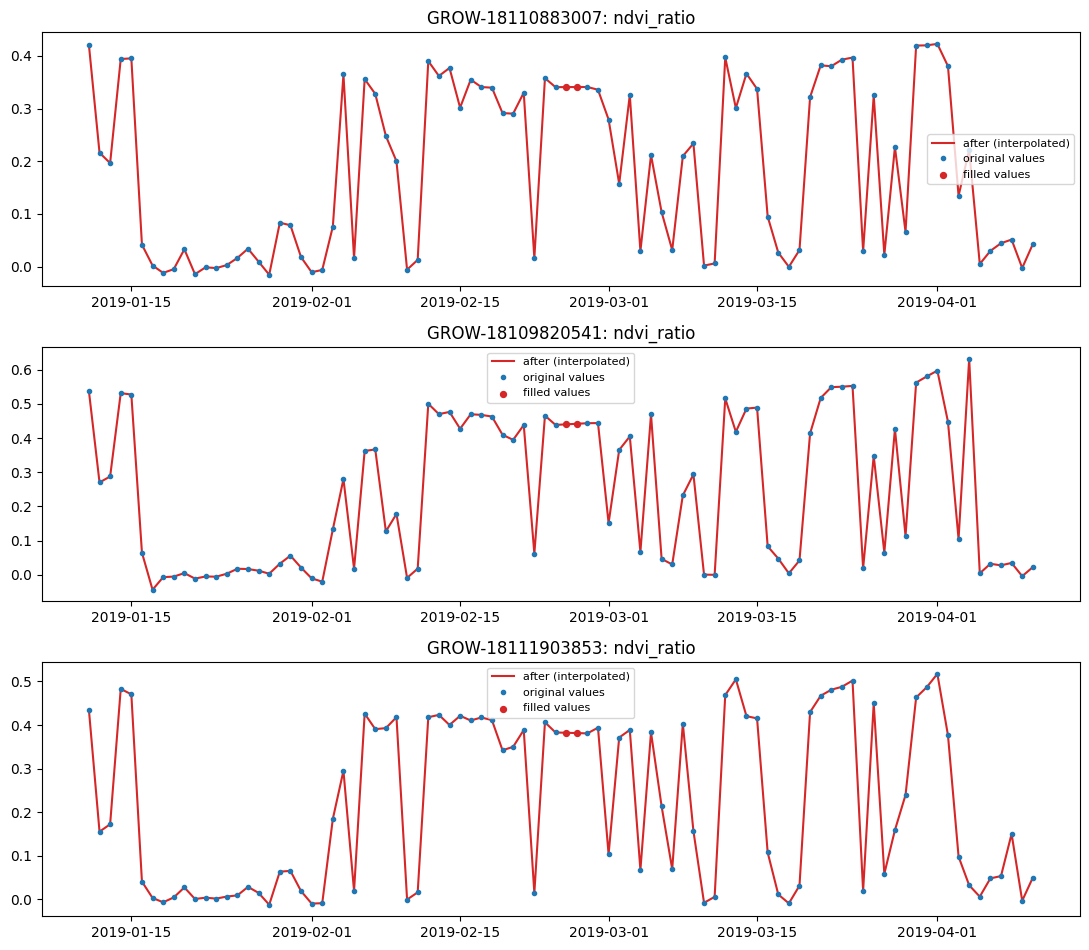

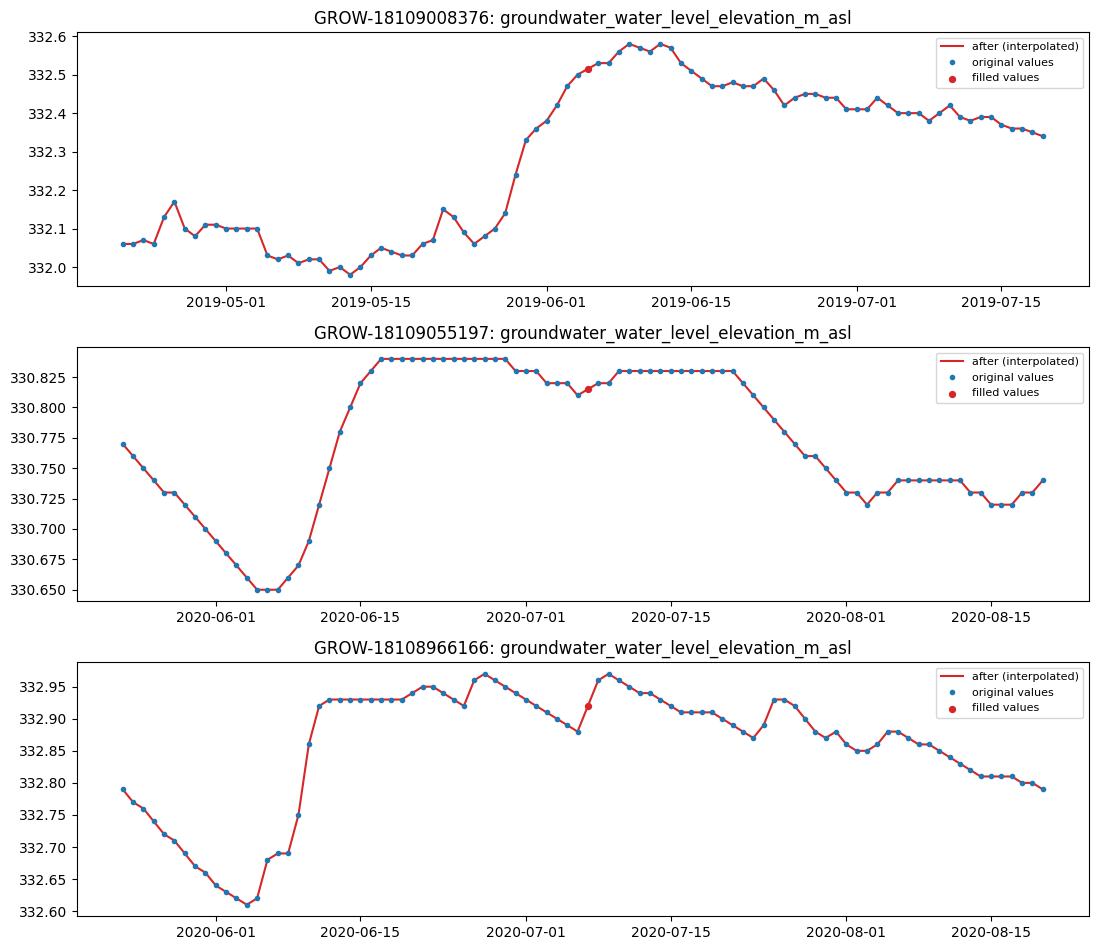

In [15]:
# Visualize interpolation: before vs after

def plot_interp(col, n_wells=3, window=45, seed=0):
  # Select wells that had gaps in this column
  gappy = df_before.loc[df_before[col].isna(), "GROW_ID"].unique()
  wells = np.random.default_rng(seed).choice(gappy, size=min(n_wells, len(gappy)), replace=False)

  fig, axes = plt.subplots(len(wells), 1, figsize=(11, 3.2 * len(wells)))
  axes = np.atleast_1d(axes)
  for ax, w in zip(axes, wells):
    b = df_before[df_before.GROW_ID == w].reset_index(drop=True)
    a = df_daily[df_daily.GROW_ID == w].reset_index(drop=True)

    # Zoom in around the first gap
    i = b[col].isna().idxmax()
    lo, hi = max(i - window, 0), min(i + window, len(b))
    b, a = b.iloc[lo:hi], a.iloc[lo:hi]
    filled = b[col].isna()

    # Plot the graphs
    ax.plot(a["date"], a[col], color="tab:red", lw=1.5, label="after (interpolated)")
    ax.plot(b["date"], b[col], color="tab:blue", marker="o", ms=3, lw=0, label="original values")
    ax.scatter(a.loc[filled, "date"], a.loc[filled, col], color="tab:red", s=18, zorder=3, label="filled values")
    ax.set_title(f"{w}: {col}")
    ax.legend(loc="best", fontsize=8)
  plt.tight_layout()
  plt.show()

for c in cols_to_interp:
  plot_interp(c)
  print("\n")

## TEMPORAL TREND & ROLLING STATISTICS ANALYSIS

We now examine how groundwater levels change over time. We first visualize the raw time series for several wells, then use rolling statistics to smooth short-term fluctuations and make longer-term trends and possible seasonal patterns easier to identify.

In [16]:
target = "groundwater_water_level_elevation_m_asl"

# Select wells with the most available groundwater observations
well_counts = (
    df_daily.groupby("GROW_ID")[target]
    .count()
    .sort_values(ascending=False)
)

selected_wells = well_counts.head(3).index.tolist()

print("Selected wells:")
for well in selected_wells:
    print(well)

Selected wells:
GROW-18108201772
GROW-18108286252
GROW-18108328402


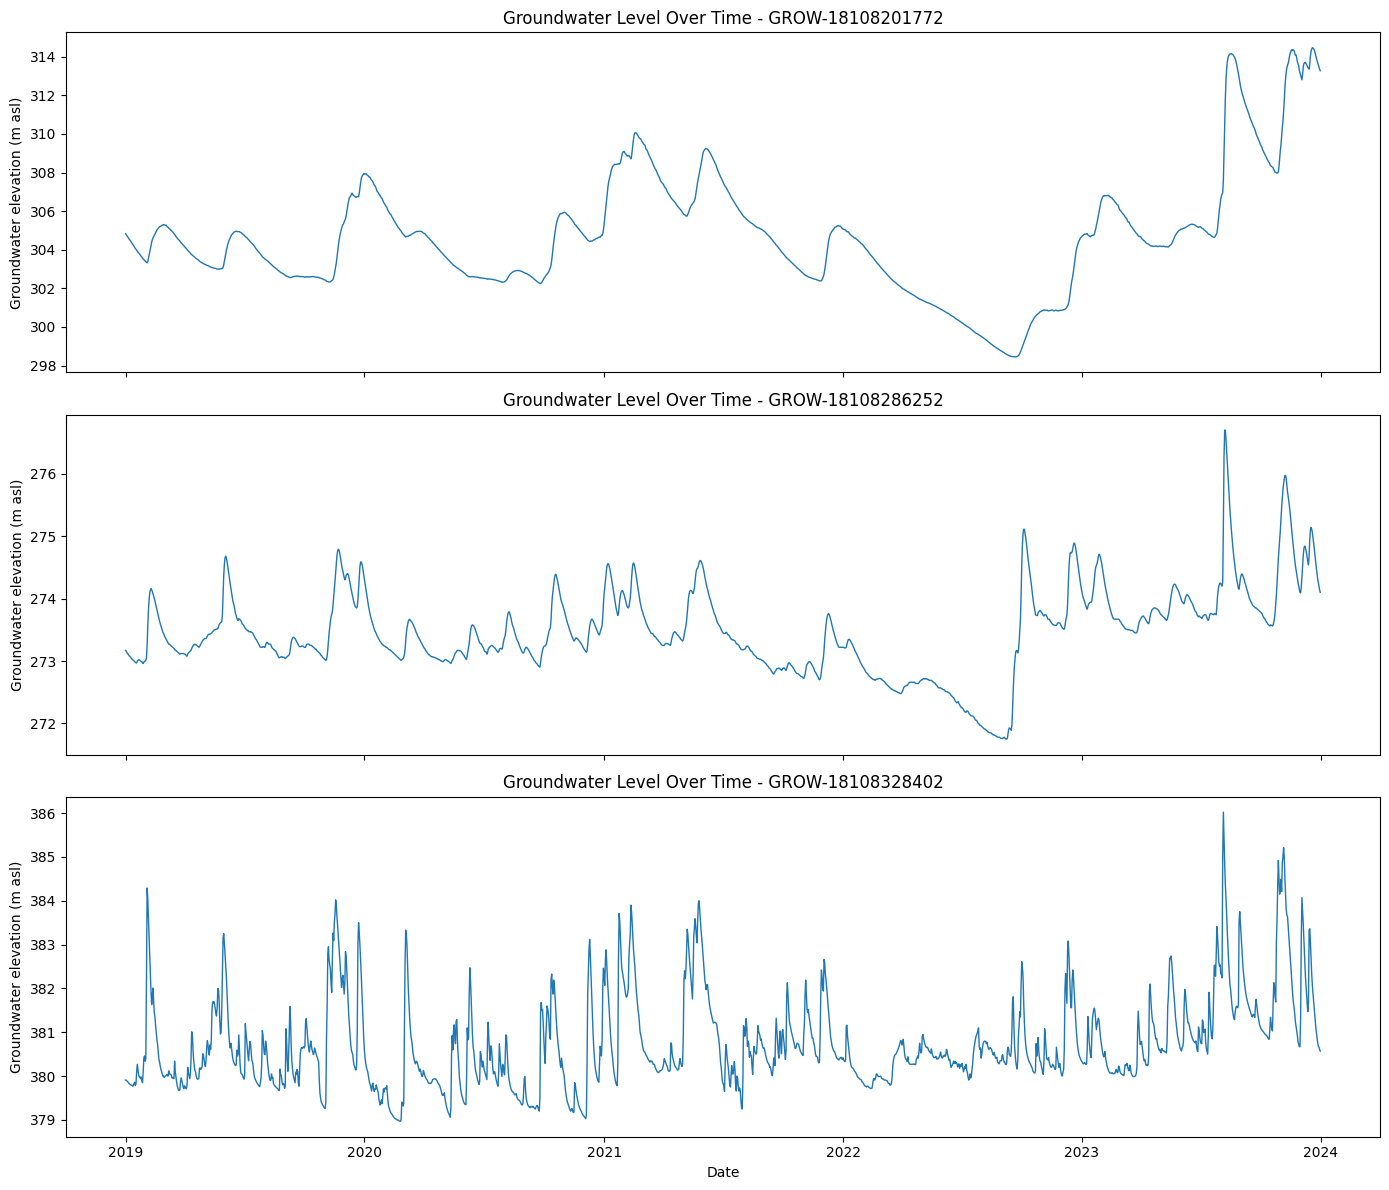

In [17]:
# Visualize groundwater levels over time for selected wells

fig, axes = plt.subplots(
    len(selected_wells),
    1,
    figsize=(14, 4 * len(selected_wells)),
    sharex=True
)

axes = np.atleast_1d(axes)

for ax, well in zip(axes, selected_wells):
    well_df = df_daily[df_daily["GROW_ID"] == well]

    ax.plot(
        well_df["date"],
        well_df[target],
        linewidth=1
    )

    ax.set_title(f"Groundwater Level Over Time - {well}")
    ax.set_ylabel("Groundwater elevation (m asl)")

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### Initial Temporal Trends

These plots show how groundwater levels change over time for individual wells. Since different wells can have different baseline groundwater elevations, it makes more sense to analyze them separately instead of averaging the raw values together. Next, rolling statistics are used to smooth short-term fluctuations and make longer-term patterns easier to see.

In [18]:
# Calculate rolling statistics separately for each well

df_daily["rolling_mean_30"] = (
    df_daily.groupby("GROW_ID")[target]
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)

df_daily["rolling_mean_90"] = (
    df_daily.groupby("GROW_ID")[target]
    .transform(lambda x: x.rolling(window=90, min_periods=1).mean())
)

df_daily["rolling_std_30"] = (
    df_daily.groupby("GROW_ID")[target]
    .transform(lambda x: x.rolling(window=30, min_periods=1).std())
)

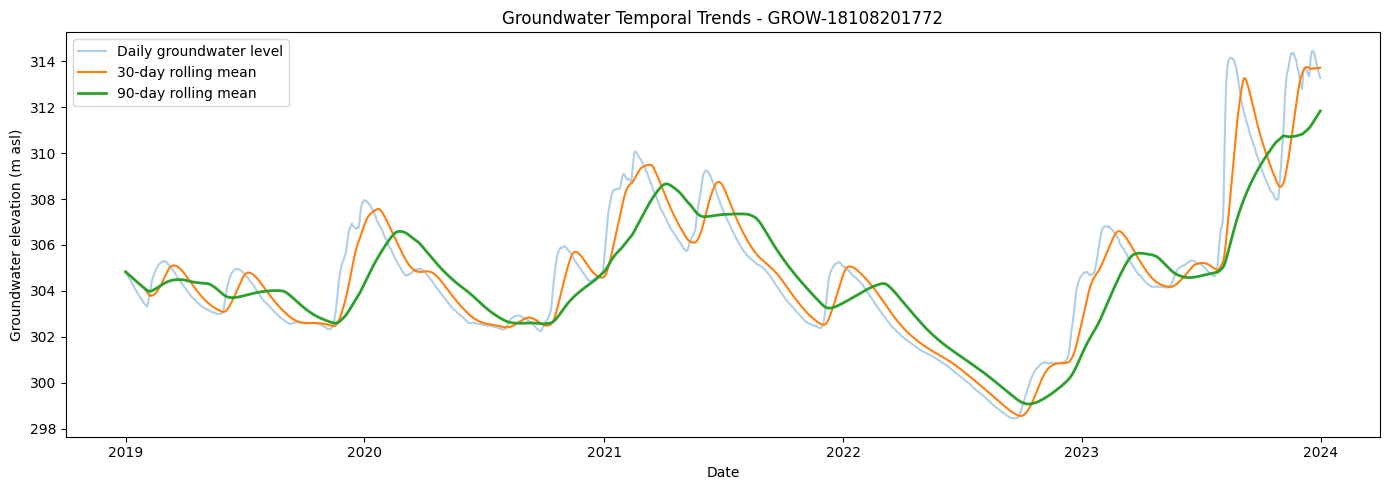

In [19]:
# Compare the original groundwater values with short- and long-term rolling averages

well = selected_wells[0]
well_df = df_daily[df_daily["GROW_ID"] == well]

plt.figure(figsize=(14, 5))

plt.plot(
    well_df["date"],
    well_df[target],
    alpha=0.35,
    label="Daily groundwater level"
)

plt.plot(
    well_df["date"],
    well_df["rolling_mean_30"],
    label="30-day rolling mean"
)

plt.plot(
    well_df["date"],
    well_df["rolling_mean_90"],
    linewidth=2,
    label="90-day rolling mean"
)

plt.title(f"Groundwater Temporal Trends - {well}")
plt.xlabel("Date")
plt.ylabel("Groundwater elevation (m asl)")
plt.legend()
plt.tight_layout()
plt.show()

### Rolling Statistics

To make the temporal patterns easier to interpret, we calculated 30-day and 90-day rolling means for each well. The 30-day rolling mean smooths short-term fluctuations, while the 90-day rolling mean gives a clearer view of longer-term changes in groundwater level.

We also calculated a 30-day rolling standard deviation to see how the amount of short-term variation changes over time. Higher rolling standard deviation values indicate periods when groundwater levels were changing more, while lower values indicate more stable periods.

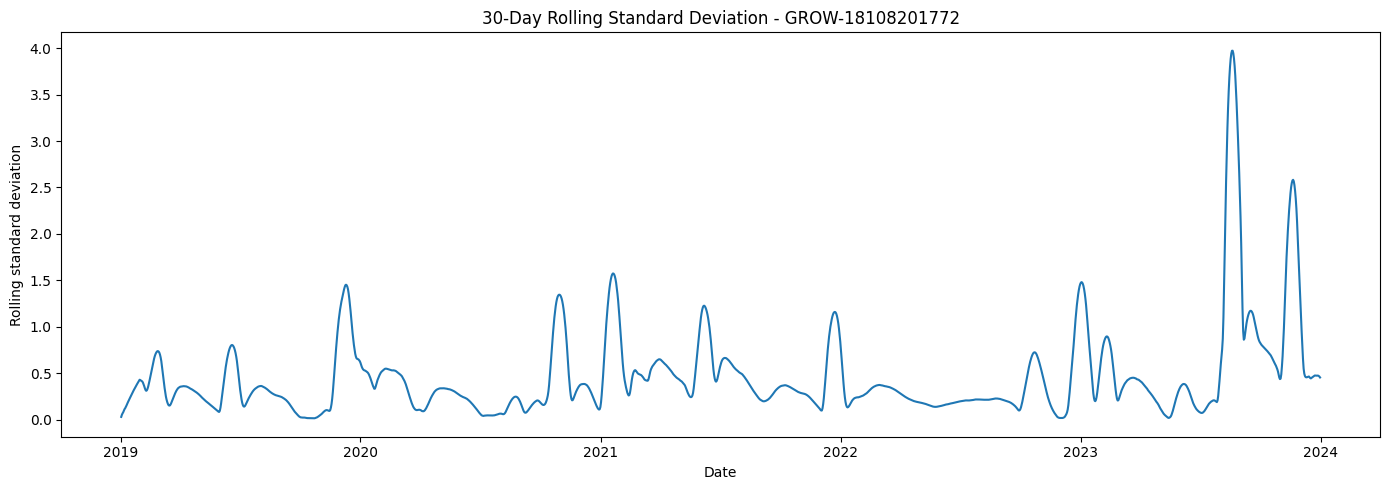

In [21]:
# Look at how the amount of short-term variation changes over time

plt.figure(figsize=(14, 5))

plt.plot(
    well_df["date"],
    well_df["rolling_std_30"]
)

plt.title(f"30-Day Rolling Standard Deviation - {well}")
plt.xlabel("Date")
plt.ylabel("Rolling standard deviation")
plt.tight_layout()
plt.show()

### Looking at Seasonality

Rolling averages help show the overall direction of groundwater levels, but they do not by themselves confirm seasonality. To look for possible seasonal patterns, we next compare groundwater levels across months to see whether similar increases or decreases tend to occur during the same parts of the year.

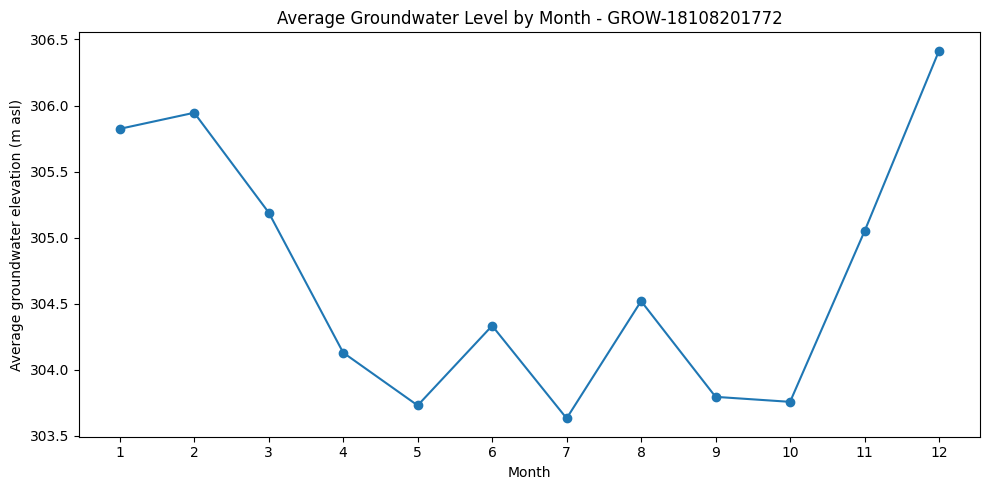

In [23]:
# Check for possible seasonal patterns by comparing average groundwater levels by month

well_df = well_df.copy()
well_df["month"] = well_df["date"].dt.month

monthly_avg = (
    well_df.groupby("month")[target]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title(f"Average Groundwater Level by Month - {well}")
plt.xlabel("Month")
plt.ylabel("Average groundwater elevation (m asl)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Observations

For this well, the rolling averages show several changes in groundwater level over time rather than one consistent increasing or decreasing trend. The 90-day rolling mean makes the longer-term changes especially clear, including a decline leading into 2022 followed by an increase through 2023.

The monthly averages also suggest a possible seasonal pattern. Average groundwater levels are generally higher around the beginning and end of the year and lower during several of the middle months. This is only an exploratory indication of seasonality, so additional analysis such as autocorrelation can be used to examine repeating patterns more closely.